# Can CMIP6 models reproduce Zambia's rainy season?

**Question.** The [observational rainfall study](https://github.com/nephatmwanza/zambia-rainfall-extremes) found that what matters most for
Zambian agriculture is not the seasonal total but the **dry spell inside the season** — a
three-week gap in January fails a maize crop in a year with entirely normal rainfall.

So before anyone uses a climate model to plan for Zambia's future, one question has to be
answered first: **can these models reproduce the present?** And specifically, can they
reproduce dry spells?

**Answer, in short: mostly no — and for a reason that turns out to be diagnosable.**

**Data.** 29 CMIP6 models, historical experiment, daily precipitation, conservatively
regridded onto the CHIRPS grid. Benchmark is CHIRPS over the 30 October–March seasons the
two records share, **1984/85 – 2013/14**.

| Index | Meaning | Units | What it isolates |
|---|---|---|---|
| `prmean` | mean rainfall per day of season | mm/day | overall bias |
| `r1mm_pct` | share of days that are wet (≥ 1 mm) | % of days | **frequency** |
| `sdii` | mean rainfall on wet days only | mm/wet day | **intensity** |
| `cdd` | longest run of consecutive dry days | days | dry spells |
| `prcptot` | season total | mm | context only |

**Why frequency and intensity are separated.** A model can produce roughly the right
seasonal total while getting there in entirely the wrong way. Splitting the total into how
*often* it rains and how *hard* is what exposes that — and it is what this whole analysis
turns on.

**A note on what cannot be compared.** CMIP6 runs are not initialised from observations, so
model year 1998 is not the real 1998 — each model generates its own internal variability.
Comparing year against year, or correlating a model's time series with CHIRPS, would be
meaningless. Everything here compares **30-season climatologies and distributions**, never
individual years.

In [1]:
import os, sys, json, warnings
import numpy as np, pandas as pd, netCDF4 as nc
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import pearsonr

ROOT = os.getcwd()
if os.path.basename(ROOT) == "notebooks":
    ROOT = os.path.dirname(ROOT)
FIGDIR = os.path.join(ROOT, "figures"); os.makedirs(FIGDIR, exist_ok=True)
print("repo root:", os.path.basename(ROOT))

repo root: Zambia_CMIP6_Evaluation


In [2]:
# ---- design tokens, consistent with the two observational studies ------------
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, RED, GREY = "#2a78d6", "#c0392f", "#9a9990"

SEQ_BLUE = LinearSegmentedColormap.from_list("seq_blue", [
    "#cde2fb","#b7d3f6","#9ec5f4","#86b6ef","#6da7ec","#5598e7",
    "#3987e5","#2a78d6","#256abf","#1c5cab","#184f95","#104281","#0d366b"])
DIV_RB = LinearSegmentedColormap.from_list("div_rb", [
    "#6b1717","#a82c2c","#d03b3b","#e88b8a","#f7c9c8",
    "#f0efec",
    "#cde2fb","#86b6ef","#3987e5","#256abf","#0d366b"])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family":"sans-serif", "font.sans-serif":["DejaVu Sans"],
    "text.color":INK, "axes.labelcolor":INK2, "xtick.color":MUTED, "ytick.color":MUTED,
    "axes.edgecolor":AXIS, "axes.linewidth":.8,
    "grid.color":GRID, "grid.linewidth":.8, "grid.linestyle":"-",
    "axes.grid":False, "axes.spines.top":False, "axes.spines.right":False,
    "font.size":9, "axes.titlesize":10, "figure.dpi":110, "savefig.dpi":160,
})

IDX  = ["prmean","r1mm_pct","sdii","cdd","prcptot"]
UNIT = {"prmean":"mm/day","r1mm_pct":"% of days","sdii":"mm/wet day","cdd":"days","prcptot":"mm"}
LAB  = {"prmean":"Mean rainfall","r1mm_pct":"Wet-day frequency","sdii":"Wet-day intensity",
        "cdd":"Longest dry spell","prcptot":"Season total"}
MODELS = json.load(open(os.path.join(ROOT,"data/processed/model_names.json")))
print(f"{len(MODELS)} models")

29 models


## Loading the climatologies

In [3]:
mk = nc.Dataset(os.path.join(ROOT,"data/processed/zambia_province_mask.nc"))
inside = np.asarray(mk.variables["province_code"][:]) >= 1
lat = np.asarray(mk.variables["lat"][:],float); lon = np.asarray(mk.variables["lon"][:],float)
mk.close()

# area weights: cos(latitude), zero outside Zambia
W = np.where(inside, np.cos(np.deg2rad(lat))[:,None]*np.ones((1,inside.shape[1])), 0.0)
def amean(f):
    ok = np.isfinite(f)
    return np.nansum(np.where(ok,f,0)*W)/np.nansum(W*ok)

def clim(path):
    # Cells outside every model's land/valid mask are all-NaN down the time axis, so
    # nanmean warns on them. They are dropped by the Zambia mask a moment later, so the
    # warning is noise - silence it rather than let it clutter the output.
    d = nc.Dataset(path)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        out = {v: np.nanmean(np.asarray(np.ma.filled(d.variables[v][:],np.nan),float),axis=0)
               for v in IDX}
    d.close(); return out

OBSc = clim(os.path.join(ROOT,"data/processed/indices/OBS.nc"))
OBS  = {v: amean(OBSc[v]) for v in IDX}
MODc = {m: clim(os.path.join(ROOT,f"data/processed/indices/M{m}.nc")) for m in MODELS}

rows=[]
for m,name in MODELS.items():
    c = MODc[m]; r = dict(model=f"M{m}", name=name)
    for v in IDX:
        r[v] = amean(c[v]); r[v+"_bias"] = amean(c[v]) - OBS[v]
    a,b = OBSc["prmean"][inside], c["prmean"][inside]
    ok = np.isfinite(a)&np.isfinite(b)
    r["pcorr"] = np.corrcoef(a[ok],b[ok])[0,1]
    rows.append(r)
df = pd.DataFrame(rows)

# composite skill: mean relative absolute error over four indices + pattern shortfall
for v in ["prmean","r1mm_pct","sdii","cdd"]:
    df[v+"_rae"] = (df[v]-OBS[v]).abs()/OBS[v]
df["skill"] = df[[v+"_rae" for v in ["prmean","r1mm_pct","sdii","cdd"]]].mean(axis=1) + (1-df.pcorr)
df = df.sort_values("skill").reset_index(drop=True)
df.insert(0,"rank",np.arange(1,len(df)+1))
df.to_csv(os.path.join(ROOT,"data/processed/model_ranking.csv"), index=False)

print("OBSERVED (CHIRPS), Zambia area-weighted, ONDJFM 1984/85-2013/14")
for v in IDX: print(f"  {LAB[v]:<22}{OBS[v]:8.2f} {UNIT[v]}")

OBSERVED (CHIRPS), Zambia area-weighted, ONDJFM 1984/85-2013/14
  Mean rainfall             5.22 mm/day
  Wet-day frequency        55.56 % of days
  Wet-day intensity         9.31 mm/wet day
  Longest dry spell        18.75 days
  Season total            951.64 mm


## The diagnosis: models rain far too often

The single clearest result in the ensemble.

In [4]:
print(f"  models wetter than observed          : {(df.prmean>OBS['prmean']).sum()}/29")
print(f"  models raining on MORE days          : {(df.r1mm_pct>OBS['r1mm_pct']).sum()}/29")
print(f"  models with weaker wet-day intensity : {(df.sdii<OBS['sdii']).sum()}/29")
print()
print(f"  observed wet-day frequency : {OBS['r1mm_pct']:.1f}% of days")
print(f"  ensemble median            : {df.r1mm_pct.median():.1f}% of days")
print(f"  ensemble range             : {df.r1mm_pct.min():.1f}% to {df.r1mm_pct.max():.1f}%")

  models wetter than observed          : 25/29
  models raining on MORE days          : 25/29
  models with weaker wet-day intensity : 18/29

  observed wet-day frequency : 55.6% of days
  ensemble median            : 71.3% of days
  ensemble range             : 44.7% to 91.3%


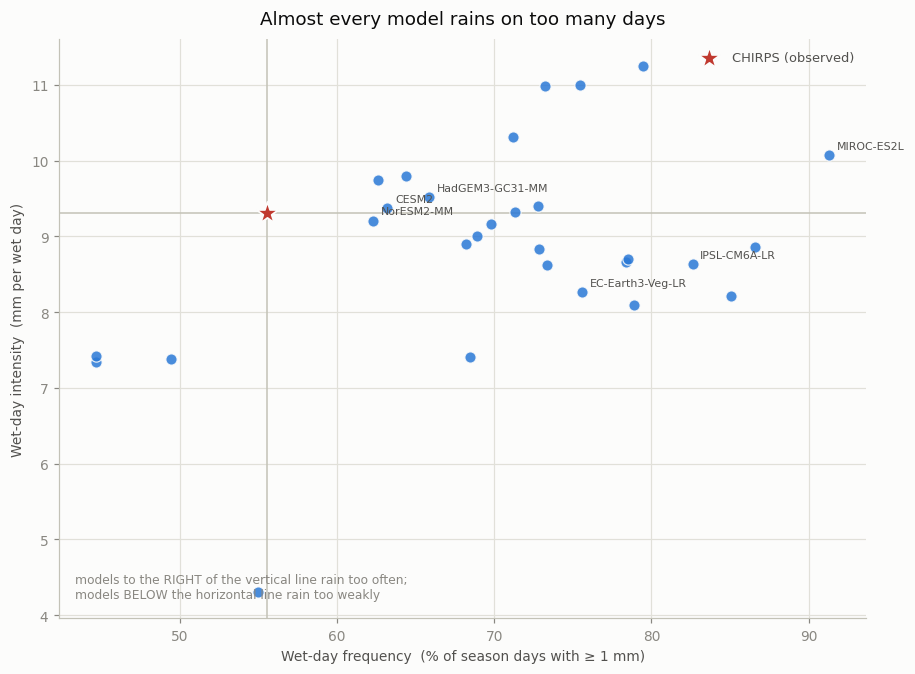

In [5]:
# ---- Figure 1: the drizzle diagnostic -----------------------------------------
fig, ax = plt.subplots(figsize=(8.2,6), constrained_layout=True)
ax.axvline(OBS["r1mm_pct"], color=AXIS, lw=1, zorder=1)
ax.axhline(OBS["sdii"],     color=AXIS, lw=1, zorder=1)
ax.scatter(df.r1mm_pct, df.sdii, s=54, color=BLUE, alpha=.85,
           edgecolor=SURFACE, linewidth=.8, zorder=3)
ax.scatter([OBS["r1mm_pct"]],[OBS["sdii"]], s=230, marker="*", color=RED,
           edgecolor=SURFACE, linewidth=1.2, zorder=5, label="CHIRPS (observed)")
for _,r in df.iterrows():
    if r["rank"]<=3 or r["rank"]>26:
        ax.annotate(r["name"], (r.r1mm_pct, r.sdii), fontsize=7.2, color=INK2,
                    xytext=(5,4), textcoords="offset points")
ax.set_xlabel("Wet-day frequency  (% of season days with ≥ 1 mm)", color=INK2)
ax.set_ylabel("Wet-day intensity  (mm per wet day)", color=INK2)
ax.set_title("Almost every model rains on too many days", color=INK, fontsize=12, pad=10)
ax.grid(True); ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=8.5, labelcolor=INK2, loc="upper right")
ax.text(.02,.03, "models to the RIGHT of the vertical line rain too often;\n"
                 "models BELOW the horizontal line rain too weakly",
        transform=ax.transAxes, fontsize=8, color=MUTED, va="bottom")
fig.savefig(os.path.join(FIGDIR,"fig1_drizzle_diagnostic.png"), bbox_inches="tight")
plt.show()

## Why that matters: the frequency error destroys dry spells

Raining too often is not merely untidy. A model that rains on 85% of days *cannot* produce a
three-week dry spell — there is no room in the calendar for one. And the dry spell is exactly
the quantity the observational study identified as the one that matters for a maize crop.

If that mechanism is real, the frequency error should predict the dry-spell error. It does.

  wet-day FREQUENCY bias vs dry-spell bias : r = -0.80  (p = 2.5e-07)
  wet-day INTENSITY bias vs dry-spell bias : r = -0.12  (p = 0.52)

  frequency explains 63% of the variance in dry-spell error
  intensity explains 2%


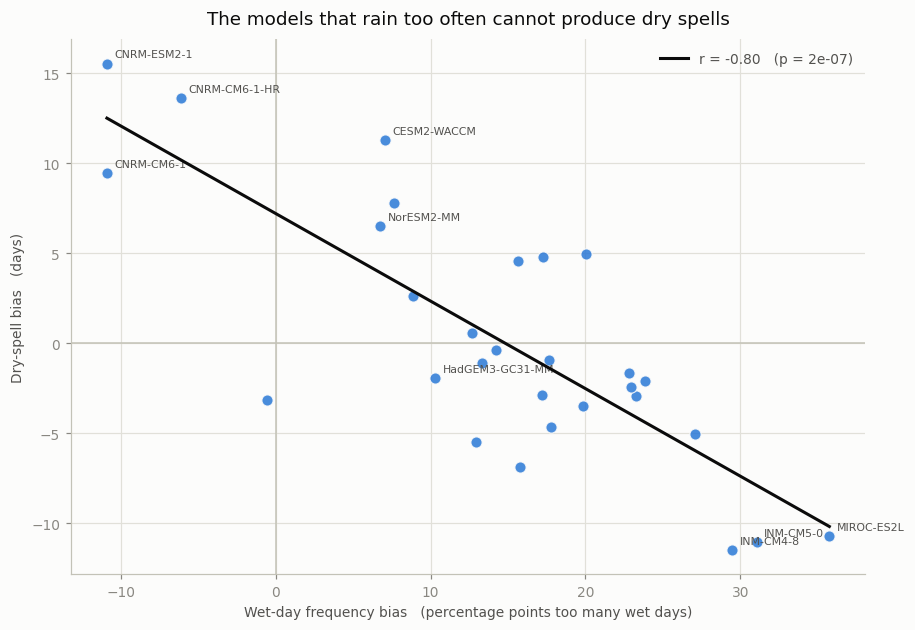

In [6]:
fb = df.r1mm_pct - OBS["r1mm_pct"]
cb = df.cdd      - OBS["cdd"]
ib = df.sdii     - OBS["sdii"]
r_f,p_f = pearsonr(fb,cb); r_i,p_i = pearsonr(ib,cb)
print(f"  wet-day FREQUENCY bias vs dry-spell bias : r = {r_f:+.2f}  (p = {p_f:.1e})")
print(f"  wet-day INTENSITY bias vs dry-spell bias : r = {r_i:+.2f}  (p = {p_i:.2f})")
print(f"\n  frequency explains {100*r_f**2:.0f}% of the variance in dry-spell error")
print(f"  intensity explains {100*r_i**2:.0f}%")

fig, ax = plt.subplots(figsize=(8.2,5.6), constrained_layout=True)
ax.axhline(0,color=AXIS,lw=1); ax.axvline(0,color=AXIS,lw=1)
ax.scatter(fb, cb, s=54, color=BLUE, alpha=.85, edgecolor=SURFACE, linewidth=.8, zorder=3)
z = np.polyfit(fb,cb,1); xs = np.linspace(fb.min(),fb.max(),50)
ax.plot(xs, np.polyval(z,xs), color=INK, lw=2, zorder=4,
        label=f"r = {r_f:.2f}   (p = {p_f:.0e})")
for _,r in df.iterrows():
    if abs(r.cdd-OBS["cdd"])>8 or r["rank"]<=2:
        ax.annotate(r["name"], (r.r1mm_pct-OBS["r1mm_pct"], r.cdd-OBS["cdd"]),
                    fontsize=7.2, color=INK2, xytext=(5,4), textcoords="offset points")
ax.set_xlabel("Wet-day frequency bias   (percentage points too many wet days)", color=INK2)
ax.set_ylabel("Dry-spell bias   (days)", color=INK2)
ax.set_title("The models that rain too often cannot produce dry spells",
             color=INK, fontsize=12, pad=10)
ax.legend(frameon=False, fontsize=9, labelcolor=INK2)
ax.grid(True); ax.set_axisbelow(True)
fig.savefig(os.path.join(FIGDIR,"fig2_frequency_drives_dryspell.png"), bbox_inches="tight")
plt.show()

## The ensemble average hides the failure

A common shortcut is to take the multi-model mean and treat it as the best estimate. Here
that would be actively misleading.

  ensemble MEDIAN dry spell :  17.1 days
  observed                  :  18.7 days   <- looks like close agreement
  but individual models span:   7.3 to 34.3 days
  models within 2 days of observed: 6/29


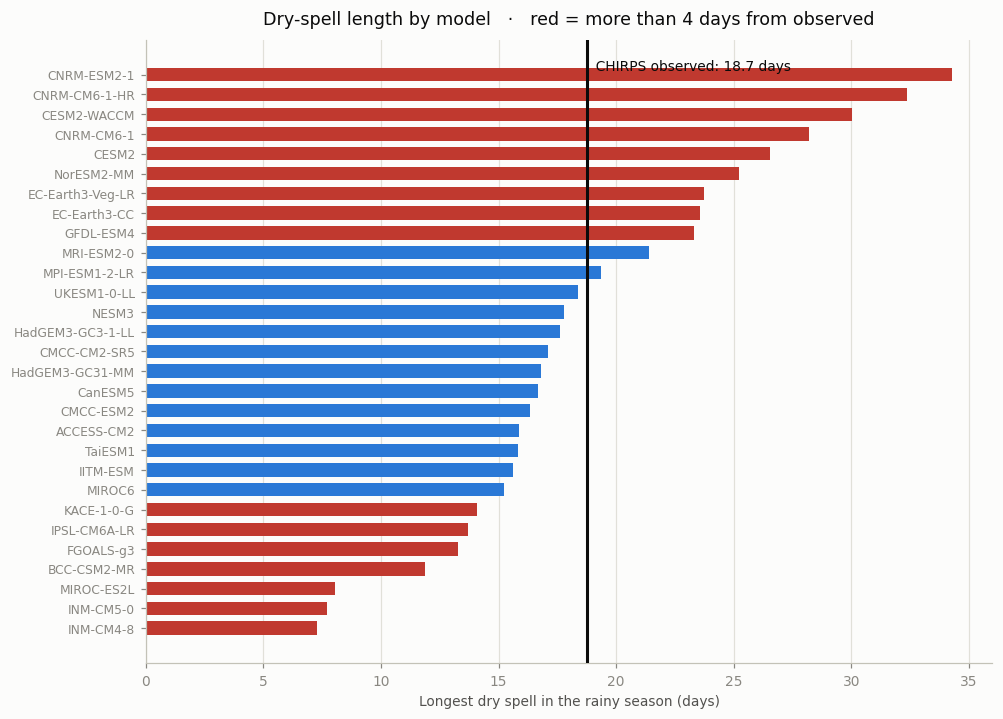

In [7]:
print(f"  ensemble MEDIAN dry spell : {df.cdd.median():5.1f} days")
print(f"  observed                  : {OBS['cdd']:5.1f} days   <- looks like close agreement")
print(f"  but individual models span: {df.cdd.min():5.1f} to {df.cdd.max():.1f} days")
within = int(((df.cdd-OBS['cdd']).abs()<=2).sum())
print(f"  models within 2 days of observed: {within}/29")

fig, ax = plt.subplots(figsize=(9,6.4), constrained_layout=True)
d = df.sort_values("cdd")
cols = [RED if abs(v-OBS["cdd"])>4 else BLUE for v in d.cdd]
y = np.arange(len(d))
ax.barh(y, d.cdd, color=cols, height=.68)
ax.axvline(OBS["cdd"], color=INK, lw=2, zorder=5)
ax.text(OBS["cdd"], len(d)-.2, f"  CHIRPS observed: {OBS['cdd']:.1f} days",
        color=INK, fontsize=9, va="top")
ax.set_yticks(y); ax.set_yticklabels(d.name, fontsize=8)
ax.set_xlabel("Longest dry spell in the rainy season (days)", color=INK2)
ax.set_title("Dry-spell length by model   ·   red = more than 4 days from observed",
             color=INK, fontsize=11.5, pad=10)
ax.xaxis.grid(True); ax.set_axisbelow(True)
fig.savefig(os.path.join(FIGDIR,"fig3_dryspell_by_model.png"), bbox_inches="tight")
plt.show()

## Which models are usable, and for what

In [8]:
print("COMPOSITE RANKING  (mean relative error over four indices, plus pattern shortfall)")
print(f"  {'#':<4}{'model':<20}{'score':>7}{'rain':>8}{'wet days':>10}{'dry spell':>11}{'pattern r':>11}")
print("  " + "-"*68)
for _,r in df.iterrows():
    tag = "  <-- best" if r["rank"]<=5 else ("  <-- worst" if r["rank"]>25 else "")
    print(f"  {int(r['rank']):<4}{r['name']:<20}{r.skill:7.2f}"
          f"{100*(r.prmean-OBS['prmean'])/OBS['prmean']:7.0f}%{r.r1mm_pct:9.0f}%"
          f"{r.cdd:10.1f}d{r.pcorr:11.2f}{tag}")

print("\nBEST OVERALL IS NOT BEST FOR DRY SPELLS")
best_dry = df.assign(e=(df.cdd-OBS['cdd']).abs()).sort_values("e").head(5)
for _,r in best_dry.iterrows():
    print(f"  {r['name']:<20} dry spell {r.cdd:5.1f}d ({r.cdd-OBS['cdd']:+.1f})  overall rank {int(r['rank'])}")

COMPOSITE RANKING  (mean relative error over four indices, plus pattern shortfall)
  #   model                 score    rain  wet days  dry spell  pattern r
  --------------------------------------------------------------------
  1   HadGEM3-GC31-MM        0.27     22%       66%      16.8d       0.87  <-- best
  2   NorESM2-MM             0.30     11%       62%      25.2d       0.85  <-- best
  3   CESM2                  0.32     15%       63%      26.5d       0.86  <-- best
  4   HadGEM3-GC3-1-LL       0.34     21%       69%      17.6d       0.79  <-- best
  5   CESM2-WACCM            0.35     18%       63%      30.0d       0.89  <-- best
  6   FGOALS-g3              0.36      3%       68%      13.3d       0.83
  7   MRI-ESM2-0             0.37     22%       64%      21.4d       0.77
  8   BCC-CSM2-MR            0.37     30%       71%      11.9d       0.86
  9   GFDL-ESM4              0.38     43%       71%      23.3d       0.88
  10  UKESM1-0-LL            0.43     24%       70%     

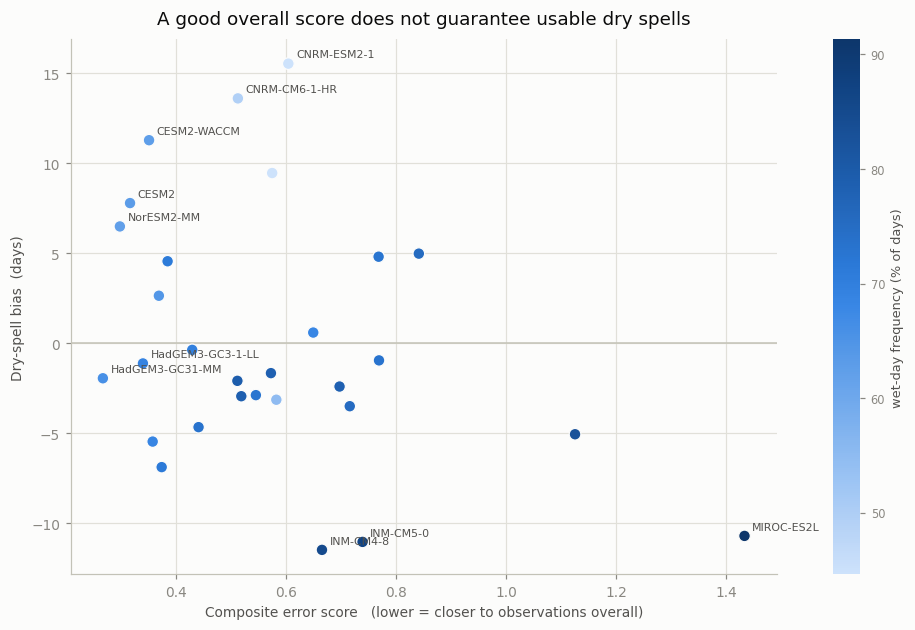

In [9]:
# ---- Figure 4: skill vs dry-spell error, the application-dependence point -----
fig, ax = plt.subplots(figsize=(8.2,5.6), constrained_layout=True)
ax.axhline(0, color=AXIS, lw=1)
sc = ax.scatter(df.skill, df.cdd-OBS["cdd"], s=58, c=df.r1mm_pct, cmap=SEQ_BLUE,
                edgecolor=SURFACE, linewidth=.8, zorder=3)
cb = fig.colorbar(sc, ax=ax, pad=.02)
cb.set_label("wet-day frequency (% of days)", color=INK2, fontsize=8.5)
cb.ax.tick_params(labelsize=7.5, colors=MUTED); cb.outline.set_visible(False)
for _,r in df.iterrows():
    if r["rank"]<=5 or abs(r.cdd-OBS["cdd"])>10:
        ax.annotate(r["name"], (r.skill, r.cdd-OBS["cdd"]), fontsize=7.2, color=INK2,
                    xytext=(5,4), textcoords="offset points")
ax.set_xlabel("Composite error score   (lower = closer to observations overall)", color=INK2)
ax.set_ylabel("Dry-spell bias  (days)", color=INK2)
ax.set_title("A good overall score does not guarantee usable dry spells",
             color=INK, fontsize=12, pad=10)
ax.grid(True); ax.set_axisbelow(True)
fig.savefig(os.path.join(FIGDIR,"fig4_skill_vs_dryspell.png"), bbox_inches="tight")
plt.show()

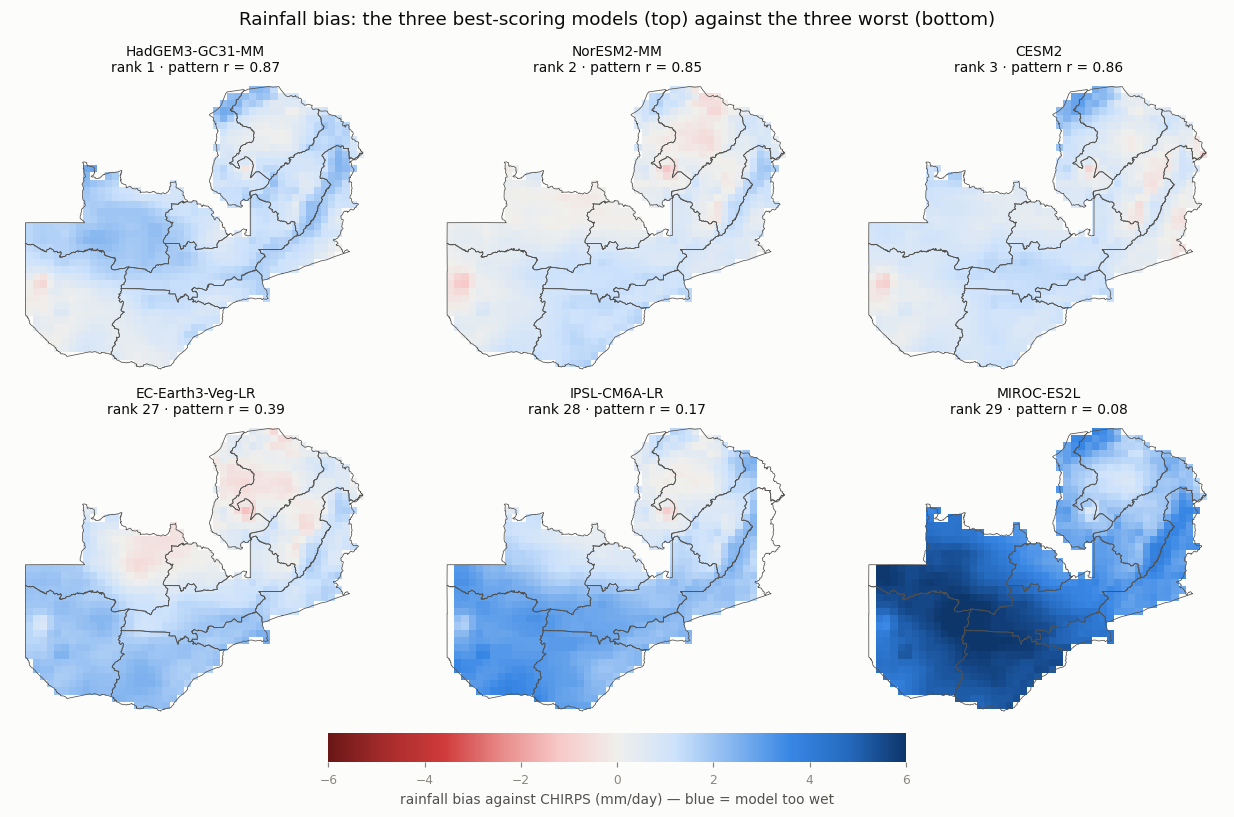

In [10]:
# ---- Figure 5: spatial rainfall bias, best three against worst three ----------
with open(os.path.join(ROOT,"boundaries/zambia_provinces_wgs84.geojson")) as f:
    PROV = json.load(f)
def basemap(ax):
    for feat in PROV["features"]:
        for ring in feat["geometry"]["coordinates"]:
            a=np.asarray(ring); ax.plot(a[:,0],a[:,1],lw=.5,color="#52514e",zorder=5)
    ax.set_xlim(21.5,34.3); ax.set_ylim(-18.4,-8.0); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)

dx,dy = lon[1]-lon[0], lat[1]-lat[0]
LON_E = np.append(lon-dx/2, lon[-1]+dx/2); LAT_E = np.append(lat-dy/2, lat[-1]+dy/2)
sel = list(df.head(3).itertuples()) + list(df.tail(3).itertuples())

fig, axes = plt.subplots(2,3, figsize=(11.5,7), constrained_layout=True)
for ax,row in zip(axes.ravel(), sel):
    mnum = row.model.replace("M","")
    b = np.where(inside, MODc[mnum]["prmean"] - OBSc["prmean"], np.nan)
    m = ax.pcolormesh(LON_E, LAT_E, b, cmap=DIV_RB, shading="flat", vmin=-6, vmax=6)
    basemap(ax)
    ax.set_title(f"{row.name}\nrank {row.rank} · pattern r = {row.pcorr:.2f}",
                 fontsize=9, color=INK, pad=5)
cb = fig.colorbar(m, ax=axes, orientation="horizontal", fraction=.045, pad=.02)
cb.set_label("rainfall bias against CHIRPS (mm/day) — blue = model too wet",
             color=INK2, fontsize=9)
cb.ax.tick_params(labelsize=8, colors=MUTED); cb.outline.set_visible(False)
fig.suptitle("Rainfall bias: the three best-scoring models (top) against the three worst (bottom)",
             color=INK, fontsize=12, y=1.04)
fig.savefig(os.path.join(FIGDIR,"fig5_spatial_bias.png"), bbox_inches="tight")
plt.show()

## What this means

**Most CMIP6 models should not be used for Zambian dry-spell or agricultural work without
bias correction.** Twenty-five of twenty-nine rain on too many days, and because a model that
rains on 85% of days has no room in the calendar for a three-week gap, the dry spell — the
variable that actually fails a maize crop — is the thing they get most wrong.

**The failure is diagnosable, not mysterious.** Wet-day frequency error explains 63% of the
variance in dry-spell error across the ensemble; intensity error explains 2%. This is the
familiar tropical drizzle problem, and here it has a direct, quantified agricultural
consequence.

**Do not take the ensemble mean and stop.** The median model produces a dry spell within two
days of observed, which looks like agreement — while individual models range from 7 to 34
days, and only 6 of 29 land within two days. The average of a set of wrong answers is not a
right answer.

**Model choice depends on the application, and the ranking alone will mislead you.** The
model closest on dry spells is UKESM1-0-LL, which ranks only 10th overall. CESM2-WACCM has
the best spatial pattern of any model (r = 0.89) yet overestimates dry spells by eleven days.
And NESM3 lands within a day of the observed dry spell while ranking 26th of 29 — it gets
that one number right with almost no spatial skill (r = 0.51), which is closer to coincidence
than competence.

The defensible picks are models that do well on **both** counts rather than either alone:
**HadGEM3-GC31-MM** (1st overall, dry spell −1.9 days, pattern r = 0.87) and
**HadGEM3-GC3-1-LL** (4th, −1.1 days, r = 0.79), with **UKESM1-0-LL** (10th, −0.4 days,
r = 0.70) worth including where dry spells are the priority. Anyone selecting models for
Zambia should select against the index they actually care about — and check that a good score
on it is not accidental.

**Where this connects.** The [observational study](https://github.com/nephatmwanza/zambia-rainfall-extremes)
found dry spells lengthening across nine of ten provinces. This evaluation says that most
climate models are poorly equipped to project that particular quantity forward — which is an
argument for bias correction, for careful model selection, and for weighting the
observational record heavily in near-term planning.

Outputs written by this notebook:

- `data/processed/model_ranking.csv` — every metric and the composite score, per model
- `figures/fig1…fig5*.png`